In [3]:
# Import public packages and functions
import os
import pandas as pd
import numpy as np
import sys
import json
from pathlib import Path
import pyvista as pv

import seaborn as sns
import matplotlib.pyplot as plt
import scikit_posthocs as sp

import warnings
warnings.filterwarnings("ignore")

# inserting the lib folder to the compiler
sys.path.insert(0, './lib')
sys.path.insert(0, './utils/')

pd.set_option("display.precision", 3)

import utils_io, utils_misc, utils_cortical_atlas, utils_plotting, utils_spatial_analysis

from lib_data import DATA_IO
from lib_Subcortical_Atlases import Distal_Atlas

# 1. DATA LOADING

In [5]:
#####################################################################
# STEP 1: Loading PSD Data
#####################################################################

# load ECOG-PSD dataframe
ECOG_PSD_controlateral = utils_io.load_ECoG_event_PSD(event_category="tapping", event_laterality="controlateral")

# concat all different dyskinesia severity dataframe into single dataframe
ECOG_PSD = pd.DataFrame()
for severity in ECOG_PSD_controlateral.keys():
    ECOG_PSD = pd.concat([ECOG_PSD, ECOG_PSD_controlateral[severity]], ignore_index=True)

# assign severity scores
ECOG_PSD["severity"] = ECOG_PSD['dyskinesia_arm']
ECOG_PSD.loc[(ECOG_PSD['severity'] != "none"), 'severity']                                        = 'LID'
ECOG_PSD.loc[(ECOG_PSD['event_start_time'] < 30)  & (ECOG_PSD['severity'] == "none"), 'severity'] = 'noLID_noDOPA'
ECOG_PSD.loc[(ECOG_PSD['event_start_time'] >= 30) & (ECOG_PSD['severity'] == "none"), 'severity'] = 'noLID_DOPA'


# arrange the dataframe
ECOG_PSD['hemisphere'] = ECOG_PSD['ECoG_hemisphere']
ECOG_PSD['channel']    = ECOG_PSD['ECoG_channel']

ECOG_PSD = ECOG_PSD[['patient', 'hemisphere', 'channel', "event_no",
                     'pre_event_theta_mean', 'pre_event_alpha_mean', 
                     'pre_event_beta_low_mean','pre_event_beta_high_mean','pre_event_gamma_mean',
                     'event_theta_mean', 'event_alpha_mean', 
                     'event_beta_low_mean','event_beta_high_mean','event_gamma_mean', 
                     'post_event_theta_mean', 'post_event_alpha_mean',
                     'post_event_beta_low_mean','post_event_beta_high_mean','post_event_gamma_mean',
                     'severity']]

features = ['pre_event_theta_mean', 'pre_event_alpha_mean', 'pre_event_beta_low_mean',
            'pre_event_beta_high_mean','pre_event_gamma_mean',
            'event_theta_mean', 'event_alpha_mean', 'event_beta_low_mean',
            'event_beta_high_mean','event_gamma_mean', 
            'post_event_theta_mean', 'post_event_alpha_mean',
            'post_event_beta_low_mean','post_event_beta_high_mean','post_event_gamma_mean'] 

#####################################################################
# STEP 2: Loading Lead Positions in Sensory-Motor STN
#####################################################################

# load ECoG channel MNI coordinates
MNI_ECoG_channels   = pd.read_pickle(DATA_IO.path_coordinates + "MNI_ECoG_channels.pkl")
MNI_ECoG_channels.x = MNI_ECoG_channels.x.abs()


#####################################################################
# STEP 3: Merge PSD and Lead Position Data
#####################################################################

dataset                     = pd.merge(ECOG_PSD, MNI_ECoG_channels[["patient","hemisphere","channel","x","y","z","AAL3_cortex"]], on=['patient', 'hemisphere', 'channel'])
dataset["severity_numeric"] = dataset['severity'].map({'noLID_noDOPA':0, 'noLID_DOPA':1, 'LID':2})
#dataset_motor               = dataset[(dataset.AAL3_cortex == "Motor cortex")]
#dataset_sensory             = dataset[(dataset.AAL3_cortex == "Sensory cortex")]


#####################################################################
# STEP 4: Adjust the Axes
#####################################################################
dataset["x"] = dataset["x"] - dataset["x"].min()
dataset["y"] = dataset["y"] - dataset["y"].min()
dataset["z"] = dataset["z"] - dataset["z"].min()

# 2. DATA EXPLORATION

In [7]:
dataset_channel_mean = dict()

dataset_channel_mean["MED-OFF"] = dataset[dataset.severity_numeric==0].groupby(["patient","hemisphere","channel"])[
                                  ["pre_event_theta_mean","pre_event_alpha_mean","pre_event_beta_low_mean", "pre_event_beta_high_mean","pre_event_gamma_mean",
                                   "event_theta_mean","event_alpha_mean","event_beta_low_mean", "event_beta_high_mean","event_gamma_mean",
                                   "post_event_theta_mean","post_event_alpha_mean","post_event_beta_low_mean","post_event_beta_high_mean","post_event_gamma_mean"]].mean().reset_index()

dataset_channel_mean["MED-ON"]  = dataset[dataset.severity_numeric==1].groupby(["patient","hemisphere","channel"])[
                                  ["pre_event_theta_mean","pre_event_alpha_mean","pre_event_beta_low_mean", "pre_event_beta_high_mean","pre_event_gamma_mean",
                                   "event_theta_mean","event_alpha_mean","event_beta_low_mean", "event_beta_high_mean","event_gamma_mean",
                                   "post_event_theta_mean","post_event_alpha_mean","post_event_beta_low_mean","post_event_beta_high_mean","post_event_gamma_mean"]].mean().reset_index()

dataset_channel_mean["LID"]     = dataset[dataset.severity_numeric==2].groupby(["patient","hemisphere","channel"])[
                                  ["pre_event_theta_mean","pre_event_alpha_mean","pre_event_beta_low_mean", "pre_event_beta_high_mean","pre_event_gamma_mean",
                                   "event_theta_mean","event_alpha_mean","event_beta_low_mean", "event_beta_high_mean","event_gamma_mean",
                                   "post_event_theta_mean","post_event_alpha_mean","post_event_beta_low_mean","post_event_beta_high_mean","post_event_gamma_mean"]].mean().reset_index()

In [8]:
dataset_channel_mean["MED-OFF"] = pd.merge(dataset_channel_mean["MED-OFF"], MNI_ECoG_channels[["patient","hemisphere","channel","x","y","z"]], 
                                           on=["patient","hemisphere","channel"])

dataset_channel_mean["MED-ON"]  = pd.merge(dataset_channel_mean["MED-ON"], MNI_ECoG_channels[["patient","hemisphere","channel","x","y","z"]], 
                                           on=["patient","hemisphere","channel"])

dataset_channel_mean["LID"]     = pd.merge(dataset_channel_mean["LID"], MNI_ECoG_channels[["patient","hemisphere","channel","x","y","z"]], 
                                           on=["patient","hemisphere","channel"])

In [10]:
dataset_channel_mean["MED-OFF"]["z"] = dataset_channel_mean["MED-OFF"]["z"] + np.abs(dataset_channel_mean["MED-OFF"]["z"].min()) # all negative values 
dataset_channel_mean["MED-OFF"]["x"] = dataset_channel_mean["MED-OFF"]["x"] - dataset_channel_mean["MED-OFF"]["x"].min()         # all positive values
dataset_channel_mean["MED-OFF"]["y"] = dataset_channel_mean["MED-OFF"]["y"] + np.abs(dataset_channel_mean["MED-OFF"]["y"].min()) # all negative values

dataset_channel_mean["MED-ON"]["z"]  = dataset_channel_mean["MED-ON"]["z"] + np.abs(dataset_channel_mean["MED-ON"]["z"].min()) # all negative values 
dataset_channel_mean["MED-ON"]["x"]  = dataset_channel_mean["MED-ON"]["x"] - dataset_channel_mean["MED-ON"]["x"].min()         # all positive values
dataset_channel_mean["MED-ON"]["y"]  = dataset_channel_mean["MED-ON"]["y"] + np.abs(dataset_channel_mean["MED-ON"]["y"].min()) # all negative values

dataset_channel_mean["LID"]["z"]     = dataset_channel_mean["LID"]["z"] + np.abs(dataset_channel_mean["LID"]["z"].min()) # all negative values 
dataset_channel_mean["LID"]["x"]     = dataset_channel_mean["LID"]["x"] - dataset_channel_mean["LID"]["x"].min()         # all positive values
dataset_channel_mean["LID"]["y"]     = dataset_channel_mean["LID"]["y"] + np.abs(dataset_channel_mean["LID"]["y"].min()) # all negative values

# 3. LME MODELLING

In [16]:
intercepts         = list()
slopes             = list()
slopes_differences = list()

for frequency_band in ["alpha", "beta_low", "beta_high", "gamma"]:
    for event_segment in ["pre", "event", "post"]:
        for MNI_axis in ["x", "y", "z"]:
            intercepts_def, slopes_def, slope_dif = utils_spatial_analysis.fit_LME_for_spatial_dynamics_single(dataset, frequency_band, event_segment, MNI_axis=MNI_axis)
            intercepts.append(intercepts_def)
            slopes.append(slopes_def)
            slopes_differences.append(slope_dif)

intercepts         = pd.concat(intercepts, ignore_index=True)
slopes             = pd.concat(slopes, ignore_index=True)
slopes_differences = pd.concat(slopes_differences, ignore_index=True)

intercepts["significant"]         = intercepts.p_value<=0.05
slopes["significant"]             = slopes.p_value<=0.05
slopes_differences["significant"] = slopes_differences.p_value<=0.05

In [17]:
def plot_spatial_characteristics(dataset_channel_mean, intercepts, slopes, frequency_band, segment, MNI_axis, x_min, x_max, y_min, y_max, axis):
    
    feature              = segment + "_" + frequency_band + "_mean"
    data_plot_intercepts = intercepts[(intercepts.frequency==frequency_band) & (intercepts.event_segment==segment) & (intercepts.axis==MNI_axis)].copy()
    data_plot_slopes     = slopes[(slopes.frequency==frequency_band) & (slopes.event_segment==segment) & (slopes.axis==MNI_axis)].copy()
    
    # subset slopes for this axis
    slopes_axis          = data_plot_slopes
    intercepts_axis      = data_plot_intercepts[["severity", "intercept", "ci_lower", "ci_upper"]]
    plot_data            = slopes_axis.merge(intercepts_axis, on="severity", suffixes=("_slope", "_intercept"))
    
    axis_vals = np.linspace(x_min, x_max, 50)
    
    # Build predicted lines from slope and intercept
    lines = []
    for _, row in plot_data.iterrows():
        
        y        = row["intercept"] + row["slope"] * axis_vals
        ci_lower = row["ci_lower_intercept"] + row["ci_lower_slope"] * axis_vals
        ci_upper = row["ci_upper_intercept"] + row["ci_upper_slope"] * axis_vals
        
        lines.append(pd.DataFrame({MNI_axis: axis_vals, "pred": y, #"ci_lower": ci_lower, "ci_upper": ci_upper,
                                   "severity": row["severity"], "significant": row["significant"]}))
    
    pred_df = pd.concat(lines, ignore_index=True)
    
    # Plot regression lines
    axis = sns.lineplot(data=pred_df, x=MNI_axis, y="pred", hue="severity", linewidth=2, ax=axis, legend=False,
                        palette=[utils_plotting.colors["noLID_noDOPA"], utils_plotting.colors["noLID_DOPA"], utils_plotting.colors["LID"]])
    
    axis = sns.scatterplot(data=dataset_channel_mean["MED-OFF"], x=MNI_axis, y=feature, s=2.5, c=utils_plotting.colors["noLID_noDOPA"], ax=axis)
    axis = sns.scatterplot(data=dataset_channel_mean["MED-ON"] , x=MNI_axis, y=feature, s=2.5, c=utils_plotting.colors["noLID_DOPA"]  , ax=axis)
    axis = sns.scatterplot(data=dataset_channel_mean["LID"]    , x=MNI_axis, y=feature, s=2.5, c=utils_plotting.colors["LID"]         , ax=axis)
    
    
    # Rightmost x-position
    x_sig = axis_vals[-1]
    
    # Loop over severity groups
    for sev in pred_df['severity'].unique():
        temp = pred_df[(pred_df['severity']==sev) & (pred_df['significant'])]
        if not temp.empty:
            # Pick the y-value at the rightmost x
            y_sig = temp.loc[temp[MNI_axis] == temp[MNI_axis].max(), 'pred'].values[0]
            axis.text(x_sig, y_sig, "*", fontsize=utils_plotting.LABEL_SIZE_title, color='black', ha='left', va='center', weight='bold')
    
    
    # Reference line at y=0
    axis.set_xlabel("", fontsize=0)
    axis.set_ylabel(f"{MNI_axis} - {frequency_band} - {segment}", fontsize=utils_plotting.LABEL_SIZE)
    
    
    # clean up spines and ticks
    for spine in axis.spines.values():
        spine.set_visible(False)
        
    axis.xaxis.set_ticks_position('none')
    axis.yaxis.set_ticks_position('none')
    
    axis.set_ylim([y_min, y_max])
    
    utils_plotting.set_axis(axis)
    
    return axis

<Figure size 640x480 with 0 Axes>

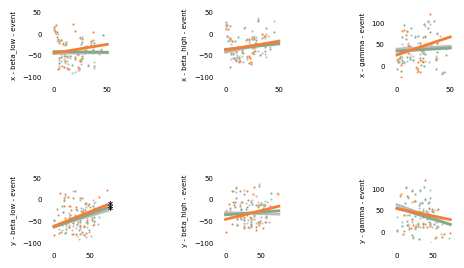

In [39]:
plt  = utils_plotting.get_figure_template()
ax1  = plt.subplot2grid((77, 66), (0, 0)  , colspan=7, rowspan=8)
ax2  = plt.subplot2grid((77, 66), (0, 20) , colspan=7, rowspan=8)
ax3  = plt.subplot2grid((77, 66), (0, 40) , colspan=7, rowspan=8)

ax4  = plt.subplot2grid((77, 66), (20, 0) , colspan=7, rowspan=8)
ax5  = plt.subplot2grid((77, 66), (20, 20), colspan=7, rowspan=8)
ax6  = plt.subplot2grid((77, 66), (20, 40), colspan=7, rowspan=8)


ax1  = plot_spatial_characteristics(dataset_channel_mean, intercepts, slopes, frequency_band="beta_low", segment="event", 
                                    MNI_axis="x", x_min=0, x_max=50, y_min=-100, y_max=50, axis=ax1)

ax2  = plot_spatial_characteristics(dataset_channel_mean, intercepts, slopes, frequency_band="beta_high", segment="event", 
                                    MNI_axis="x", x_min=0, x_max=50, y_min=-100, y_max=50, axis=ax2) 

ax3  = plot_spatial_characteristics(dataset_channel_mean, intercepts, slopes, frequency_band="gamma", segment="event", 
                                    MNI_axis="x", x_min=0, x_max=50, y_min=-25, y_max=125, axis=ax3) 

ax4  = plot_spatial_characteristics(dataset_channel_mean, intercepts, slopes, frequency_band="beta_low", segment="event", 
                                    MNI_axis="y", x_min=0, x_max=75, y_min=-100, y_max=50, axis=ax4)

ax5  = plot_spatial_characteristics(dataset_channel_mean, intercepts, slopes, frequency_band="beta_high", segment="event", 
                                    MNI_axis="y", x_min=0, x_max=75, y_min=-100, y_max=50, axis=ax5) 

ax6  = plot_spatial_characteristics(dataset_channel_mean, intercepts, slopes, frequency_band="gamma", segment="event", 
                                    MNI_axis="y", x_min=0, x_max=75, y_min=-25, y_max=125, axis=ax6) 

plt.savefig(DATA_IO.path_figure + f"spatial_analyses/cortex/event_dynamics.svg", dpi=1200)

In [19]:
slopes[(slopes.event_segment=="event") & (slopes.axis=="y") & (slopes.significant==True)]

,severity,slope,ci_lower,ci_upper,p_value,frequency,axis,event_segment,significant
39,MED-OFF,0.497,0.033,0.961,0.036,beta_low,y,event,True
40,MED-ON,0.593,0.118,1.068,0.029,beta_low,y,event,True
41,LID,0.657,0.183,1.130,0.020,beta_low,y,event,True


In [20]:
slopes_differences[(slopes_differences.event_segment=="event") & (slopes_differences.axis=="y") & (slopes_differences.significant==True)]

,comparison,slope_diff,ci_lower,ci_upper,p_value,frequency,axis,event_segment,significant
66,noLID-noDOPA vs noLID-DOPA,-0.169,-0.324,-0.013,3.797e-02,beta_high,y,event,True
67,noLID-DOPA vs LID,-0.278,-0.511,-0.046,3.797e-02,beta_high,y,event,True
68,noLID-noDOPA vs LID,-0.447,-0.663,-0.231,1.555e-04,beta_high,y,event,True


In [21]:
slopes[(slopes.event_segment=="event") & (slopes.axis=="x") & (slopes.significant==True)]

,severity,slope,ci_lower,ci_upper,p_value,frequency,axis,event_segment,significant


In [22]:
slopes_differences[(slopes_differences.event_segment=="event") & (slopes_differences.axis=="x") & (slopes_differences.significant==True)]

,comparison,slope_diff,ci_lower,ci_upper,p_value,frequency,axis,event_segment,significant
63,noLID-noDOPA vs noLID-DOPA,0.271,0.111,0.431,0.003,beta_high,x,event,True
91,noLID-DOPA vs LID,-0.687,-1.106,-0.269,0.003,gamma,x,event,True
92,noLID-noDOPA vs LID,-0.700,-1.119,-0.282,0.003,gamma,x,event,True


# 5. PLOTS

<Figure size 640x480 with 0 Axes>

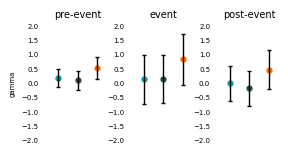

<Figure size 640x480 with 0 Axes>

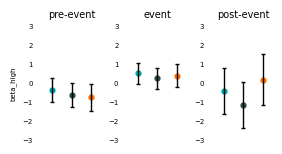

<Figure size 640x480 with 0 Axes>

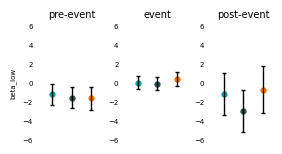

<Figure size 640x480 with 0 Axes>

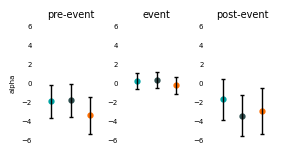

<Figure size 640x480 with 0 Axes>

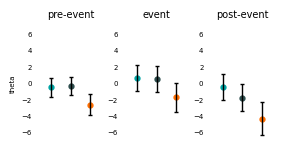

In [12]:
MNI_axis = "x"
plot_spatial_gradients(slopes, structure="cortex", frequency="gamma"    , MNI_axis=MNI_axis, ylim_min=-2, ylim_max=2)
plot_spatial_gradients(slopes, structure="cortex", frequency="beta_high", MNI_axis=MNI_axis, ylim_min=-3, ylim_max=3)
plot_spatial_gradients(slopes, structure="cortex", frequency="beta_low" , MNI_axis=MNI_axis, ylim_min=-6, ylim_max=6)
plot_spatial_gradients(slopes, structure="cortex", frequency="alpha"    , MNI_axis=MNI_axis, ylim_min=-6, ylim_max=6)
plot_spatial_gradients(slopes, structure="cortex", frequency="theta"    , MNI_axis=MNI_axis, ylim_min=-7, ylim_max=7)

<Figure size 640x480 with 0 Axes>

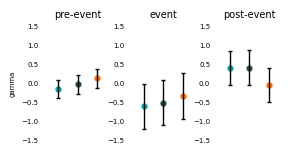

<Figure size 640x480 with 0 Axes>

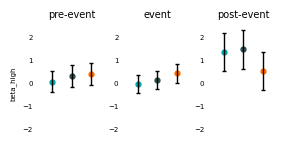

<Figure size 640x480 with 0 Axes>

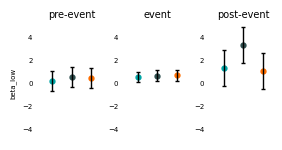

<Figure size 640x480 with 0 Axes>

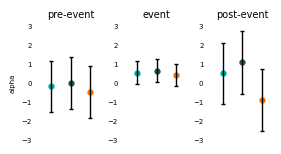

<Figure size 640x480 with 0 Axes>

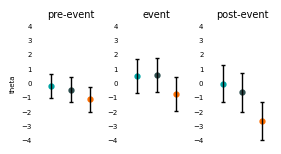

In [13]:
MNI_axis = "y"
plot_spatial_gradients(slopes, structure="cortex", frequency="gamma"    , MNI_axis=MNI_axis, ylim_min=-1.5, ylim_max=1.5)
plot_spatial_gradients(slopes, structure="cortex", frequency="beta_high", MNI_axis=MNI_axis, ylim_min=-2.5, ylim_max=2.5)
plot_spatial_gradients(slopes, structure="cortex", frequency="beta_low" , MNI_axis=MNI_axis, ylim_min=-5, ylim_max=5)
plot_spatial_gradients(slopes, structure="cortex", frequency="alpha"    , MNI_axis=MNI_axis, ylim_min=-3, ylim_max=3)
plot_spatial_gradients(slopes, structure="cortex", frequency="theta"    , MNI_axis=MNI_axis, ylim_min=-4, ylim_max=4)

In [14]:
conditions                  = [slopes_differences['p_value'] <= 0.001, slopes_differences['p_value'] <= 0.01, slopes_differences['p_value'] <= 0.05]
choices                     = ['***', '**', '*']
slopes_differences['stars'] = np.select(conditions, choices, default='')

In [46]:
slopes[(slopes.axis=="y") & (slopes.frequency=="gamma")]

,severity,slope,ci_lower,ci_upper,p_value,frequency,axis,event_segment,significant
75,noLID_noDOPA,-0.148,-0.387,0.091,0.677,gamma,y,pre,False
76,noLID_DOPA,-0.033,-0.286,0.219,0.795,gamma,y,pre,False
77,LID,0.132,-0.117,0.381,0.677,gamma,y,pre,False
81,noLID_noDOPA,-0.605,-1.194,-0.017,0.132,gamma,y,event,False
82,noLID_DOPA,-0.507,-1.107,0.093,0.196,gamma,y,event,False
83,LID,-0.335,-0.934,0.264,0.273,gamma,y,event,False
87,noLID_noDOPA,0.397,-0.040,0.834,0.226,gamma,y,post,False
88,noLID_DOPA,0.406,-0.044,0.857,0.226,gamma,y,post,False
89,LID,-0.043,-0.492,0.405,0.850,gamma,y,post,False


In [56]:
slopes_differences[(slopes_differences.axis=="y") & (slopes_differences.frequency=="gamma")]

,comparison,slope_diff,ci_lower,ci_upper,p_value,frequency,axis,event_segment,significant,stars
75,noLID-noDOPA vs noLID-DOPA,-0.114,-0.272,0.043,0.307,gamma,y,pre,False,
76,noLID-DOPA vs LID,-0.165,-0.392,0.062,0.307,gamma,y,pre,False,
77,noLID-noDOPA vs LID,-0.280,-0.490,-0.069,0.028,gamma,y,pre,True,*
81,noLID-noDOPA vs noLID-DOPA,-0.098,-0.318,0.121,0.611,gamma,y,event,False,
82,noLID-DOPA vs LID,-0.172,-0.501,0.157,0.611,gamma,y,event,False,
83,noLID-noDOPA vs LID,-0.270,-0.577,0.036,0.251,gamma,y,event,False,
87,noLID-noDOPA vs noLID-DOPA,-0.010,-0.219,0.200,0.929,gamma,y,post,False,
88,noLID-DOPA vs LID,0.450,0.139,0.760,0.009,gamma,y,post,True,**
89,noLID-noDOPA vs LID,0.440,0.152,0.728,0.008,gamma,y,post,True,**
